# 21 — Full-Waveform Inversion with complex medium and irregular free-surface topography (IBM-FWI)

This notebook demonstrates 2-D acoustic FWI in a medium with a **complex velocity
model** (vertical gradient + high-velocity layer + circular anomaly) beneath an
irregular free surface, using the Immersed Boundary Method (IBM) of
Li et al. (2020, *J. Geophys. Eng.* 17, 643–660).

The true model contains three features the initial model lacks:
- A **vertical gradient** (1.5 → 2.0 km/s from top to bottom)
- A **high-velocity layer** (2.5 km/s, 100 m thick)
- A **circular anomaly** (2.8 km/s, 150 m radius)

The initial model is a smooth gradient-only version.  The direct and
refracted waves therefore differ between observed and synthetic data,
giving a rich gradient that tests the IBM adjoint-state formulation.

In [1]:
# NBVAL_IGNORE_OUTPUT
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from examples.seismic.acoustic_topo.model import ModelTopo
from examples.seismic.acoustic_topo.wavesolver import AcousticTopoSolver
from examples.seismic.utils import AcquisitionGeometry

## Model setup: complex medium with Gaussian hill topography

We build a 2 km × 2 km domain with three superimposed velocity features
below a Gaussian hill free surface ($\rho = 1$ g/cm³ everywhere):

- **Gradient**: $v(z) = 1.5 + 0.5 \cdot z / z_{\max}$ km/s
- **Layer**: $v = 2.5$ km/s at depth 400–500 m
- **Circle**: $v = 2.8$ km/s, centre (1 km, 700 m), radius 150 m

Grid points with physical depth $z < z_0(x)$ are ghost points;  all others
are physical-domain points where the wave equation is solved.

In [2]:
# NBVAL_IGNORE_OUTPUT
# ── grid parameters ─────────────────────────────────────────────────────────
nx, nz = 201, 201        # physical grid cells
dx, dz = 10., 10.        # grid spacing (metres)
nbl = 20                 # absorbing boundary layers

shape   = (nx, nz)
spacing = (dx, dz)
origin  = (0., 0.)

# ── Gaussian hill: z_flat=50 m, A=100 m, sigma=300 m, centred at x=1 km ────
x_phys = np.linspace(0., (nx - 1) * dx, nx)    # m
z_flat, A, x0, sigma = 350., 300., 1000., 200.
topofun = lambda x: z_flat - A * np.exp(-0.5 * ((x - x0) / sigma)**2)
topo = topofun(x_phys)

# ── complex true velocity: gradient + layer + circle ────────────────────────
z_vals = np.linspace(1.5, 2.0, nz, dtype=np.float32)          # (nz,) gradient
v_true = z_vals[np.newaxis, :] + np.zeros(shape, dtype=np.float32)  # (nx, nz)

# High-velocity layer at z = 400–500 m  (iz 40–49)
v_true[:, 40:50] = 2.5

# Circle anomaly: centre (1 km, 700 m), radius 150 m
cx, cy, r = 1000, 700, 150
ix_c, iz_c = int(cx / dx), int(cy / dz)
X, Z = np.meshgrid(np.arange(nx), np.arange(nz), indexing='ij')
circle = (X - ix_c)**2 + (Z - iz_c)**2 <= (r / dx)**2
v_true[circle] = 2.8

# ── smooth initial model: gradient only ──────────────────────────────────────
v_init = z_vals[np.newaxis, :] + np.zeros(shape, dtype=np.float32)

rho = 1.0 * np.ones(shape, dtype=np.float32)   # g/cm³

# ── build models ─────────────────────────────────────────────────────────────
model0 = ModelTopo(origin=origin, spacing=spacing, shape=shape,
                  space_order=4, v=v_init, rho=rho, topo=topo,
                  nbl=nbl, bcs='mask')

model = ModelTopo(origin=origin, spacing=spacing, shape=shape,
                  space_order=4, v=v_true, rho=rho, topo=topo,
                  nbl=nbl, bcs='mask')

print(f"Physical grid     : {nx} × {nz} cells,  {dx:.0f} m spacing")
print(f"Ghost points      : {len(model.ghost_coords)}")
print(f"Critical Δt       : {model.critical_dt:.3f} ms")
print(f"Critical Δt       : {model0.critical_dt:.3f} ms")

# Ghost mask for the physical (unpadded) domain.
_is_ghost = model._build_surface_mask()[nbl:nbl + nx, 0:nz]

Operator `initdamp` ran in 0.01 s
Operator `initdamp` ran in 0.01 s


Physical grid     : 201 × 201 cells,  10 m spacing
Ghost points      : 5593
Critical Δt       : 1.981 ms
Critical Δt       : 2.773 ms


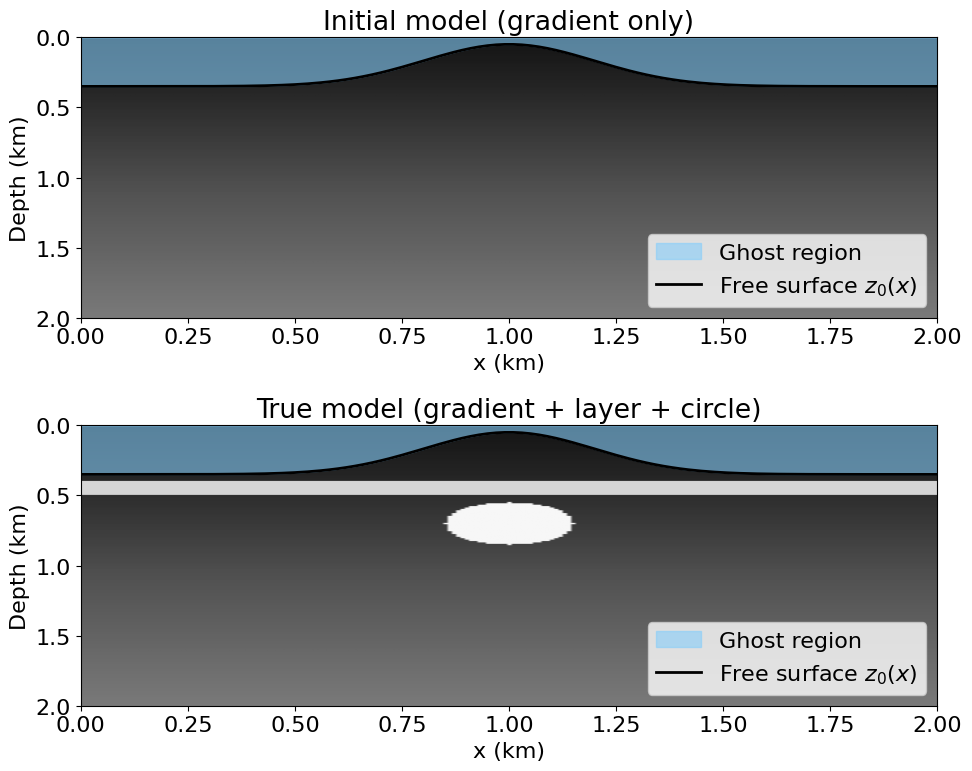

In [3]:
# NBVAL_IGNORE_OUTPUT
x_km = x_phys * 1e-3
z_km = np.linspace(0., (nz - 1) * dz * 1e-3, nz)

fig, axs = plt.subplots(2, 1, figsize=(10, 8))
for ax, v_buff, title in zip(axs,
    [v_init, v_true],
    ['Initial model (gradient only)', 'True model (gradient + layer + circle)']):
    im = ax.imshow(v_buff.T, cmap='Greys_r',
            extent=[x_km[0], x_km[-1], z_km[-1], z_km[0]],
            aspect='auto', vmin=1.4, vmax=2.9)
    ax.fill_between(x_km, z_km[0], topo * 1e-3,
                    color='lightskyblue', alpha=0.6, label='Ghost region')
    ax.plot(x_km, topo * 1e-3, 'k-', lw=2, label='Free surface $z_0(x)$')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('Depth (km)')
    ax.set_title(title)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Acquisition geometry

A single **Ricker-wavelet source** ($f_0 = 25$ Hz) is placed below the hill peak,
and a dense **receiver line** spans the full model at the same depth.

In [4]:
# NBVAL_IGNORE_OUTPUT
src_x = 1000.                      # m — below the 150 m hill peak
src_z = topofun(src_x) + dz
rec_x = np.linspace(0., (nx - 1) * dx, nx)      # m
rec_z = topofun(rec_x) + dz

src_pos = np.array([[src_x, src_z]])
rec_pos = np.column_stack([rec_x, rec_z])

t0, tn = 0., 1000.                               # ms
geom = AcquisitionGeometry(model, rec_pos, src_pos,
                           t0=t0, tn=tn, src_type='Ricker', f0=0.01)

print(f"Time steps : {geom.nt},  dt = {geom.dt:.3f} ms,  tn = {tn:.0f} ms")

Time steps : 506,  dt = 1.981 ms,  tn = 1000 ms


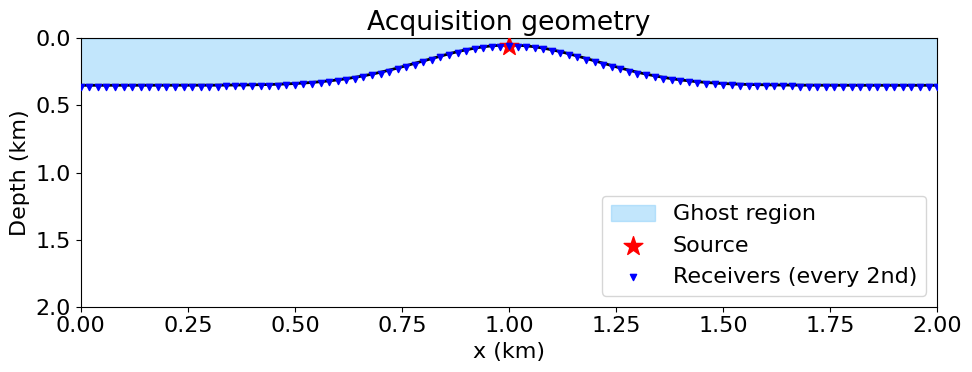

In [5]:
# NBVAL_IGNORE_OUTPUT
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(x_km, z_km[0], topo * 1e-3,
                color='lightskyblue', alpha=0.5, label='Ghost region')
ax.plot(x_km, topo * 1e-3, 'k-', lw=2)
ax.scatter([src_x * 1e-3], [src_z * 1e-3], c='red', s=200, zorder=5,
           marker='*', label='Source')
ax.scatter(rec_x[::2] * 1e-3, rec_z[::2] * 1e-3, c='blue', s=20,
           marker='v', zorder=5, label='Receivers (every 2nd)')
ax.set_xlim(x_km[0], x_km[-1])
ax.set_ylim(z_km[-1], z_km[0])
ax.set_xlabel('x (km)')
ax.set_ylabel('Depth (km)')
ax.set_title('Acquisition geometry')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## IBM forward propagation

The time loop runs manually: for each step $t$,
1. the Devito FD operator advances the pressure field by one step, then
2. `ibm_step` iterates the ghost-point correction until convergence.

We use `save=True` to retain the full time history for snapshot visualisation.

In [6]:
# NBVAL_IGNORE_OUTPUT
from examples.seismic import Receiver

d_obs = Receiver(name='d_obs', grid=model.grid,
                    time_range=geom.time_axis,
                    coordinates=geom.rec_positions)
d_syn = Receiver(name='d_syn', grid=model.grid,
                    time_range=geom.time_axis,
                    coordinates=geom.rec_positions)

solver = AcousticTopoSolver(model, geom, space_order=4)
solver.forward(model=model, rec=d_obs, save=False)
solver.forward(model=model0, rec=d_syn, save=False)

Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

(d_syn(time, p_d_syn),
 p(t, x, y),
 PerformanceSummary([(PerfKey(name='section0', rank=None),
                      PerfEntry(time=5.6e-05, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                     (PerfKey(name='section1', rank=None),
                      PerfEntry(time=1e-06, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                     (PerfKey(name='section2', rank=None),
                      PerfEntry(time=2e-06, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))]))

In [7]:
from devito import Eq, Operator
rec_diff = solver.geometry.rec
diff_eq = Eq(rec_diff, d_syn.subs({d_syn.dimensions[-1]: rec_diff.dimensions[-1]}) -
                        d_obs.subs({d_obs.dimensions[-1]: rec_diff.dimensions[-1]}))
Operator(diff_eq)()

Operator `Kernel` ran in 0.01 s


PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=3.7e-05, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

### Shot record

The shot record shows clear differences between the observed (true model)
and synthetic (initial model) data.  Unlike the homogeneous test in notebook
20, the **direct and refracted waves** differ because the true model has a
layer and circle anomaly that alter traveltimes and amplitudes.

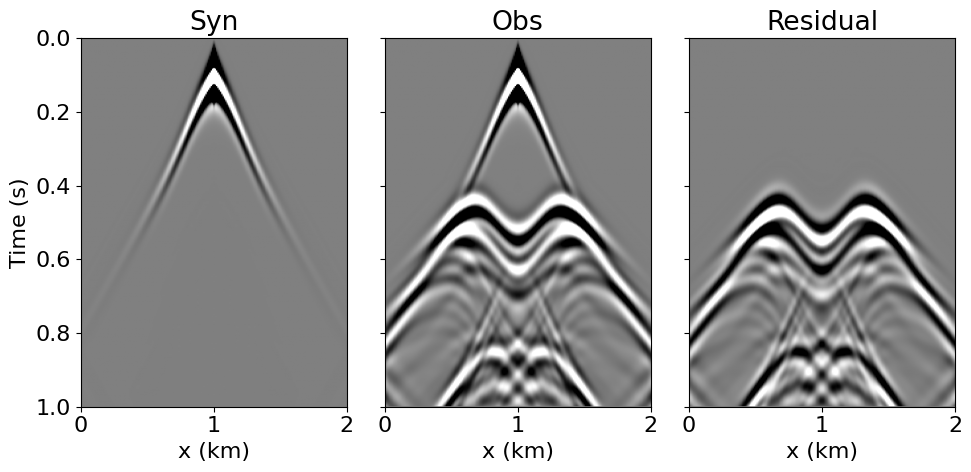

In [8]:
# NBVAL_IGNORE_OUTPUT
rec_data = np.asarray(d_syn.data)              # (nt, nrec)
scale    = np.max(np.abs(rec_data)) / 1e2
extent_r = [x_km[0], x_km[-1], tn * 1e-3, t0]  # x in km, t in s

fig, axs = plt.subplots(1, 3, figsize=(10, 5), sharey=True)
for ax, buff, title in zip(axs, [d_syn, d_obs, rec_diff], ['Syn', 'Obs', 'Residual'], strict=False):
    ax.imshow(buff.data, vmin=-scale, vmax=scale, cmap='gray',
            extent=extent_r, aspect='auto')
    ax.set_xlabel('x (km)')
    ax.set_title(title)
axs[0].set_ylabel('Time (s)')
plt.tight_layout()
plt.show()

In [9]:
# Computes the residual between observed and synthetic data into the residual
def compute_residual(residual, dobs, dsyn):
    if residual.grid.distributor.is_parallel:
        # If we run with MPI, we have to compute the residual via an operator
        # First make sure we can take the difference and that receivers are at the
        # same position
        assert np.allclose(dobs.coordinates.data[:], dsyn.coordinates.data)
        assert np.allclose(residual.coordinates.data[:], dsyn.coordinates.data)
        # Create a difference operator
        diff_eq = Eq(residual, dsyn.subs({dsyn.dimensions[-1]: residual.dimensions[-1]}) -
                               dobs.subs({dobs.dimensions[-1]: residual.dimensions[-1]}))
        Operator(diff_eq)()
    else:
        # A simple data difference is enough in serial
        residual.data[:] = dsyn.data[:] - dobs.data[:]

    return residual

In [10]:
from devito import Function, norm
nshots = 1
source_locations = src_pos
def fwi_gradient(model_changing, d_obs_list):
    # Create symbols to hold the gradient
    grad = Function(name="grad", grid=model.grid)
    # Create placeholders for the data residual and data
    residual = Receiver(name='residual', grid=model.grid,
                        time_range=geom.time_axis,
                        coordinates=geom.rec_positions)
    d_obs = Receiver(name='d_obs', grid=model.grid,
                     time_range=geom.time_axis,
                     coordinates=geom.rec_positions)
    d_syn = Receiver(name='d_syn', grid=model.grid,
                     time_range=geom.time_axis,
                     coordinates=geom.rec_positions)
    objective = 0.
    for i in range(nshots):
        # Update source location
        geom.src_positions[0, :] = source_locations[i, :]

        # Retrieve synthetic data (pseudo observed)
        d_obs.data[:] = d_obs_list[i].data[:]

        _, u0, _ = solver.forward(model=model_changing, save=True, rec=d_syn)

        # Compute gradient from data residual and update objective function
        compute_residual(residual, d_obs, d_syn)

        objective += .5*norm(residual)**2
        solver.gradient(rec=residual, p=u0, model=model_changing, grad=grad)
        # Zero out gradient above the free surface
        ghost_mask = model_changing._build_surface_mask()
        grad.data[:] *= ~ghost_mask

    return objective, grad


In [11]:
model_changing = ModelTopo(origin=origin, spacing=spacing, shape=shape,
                  space_order=4, v=v_init.copy(), rho=rho, topo=topo,
                  nbl=nbl, bcs='mask')
ff, update = fwi_gradient(model_changing=model_changing, d_obs_list=[d_obs])

Operator `initdamp` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Oper

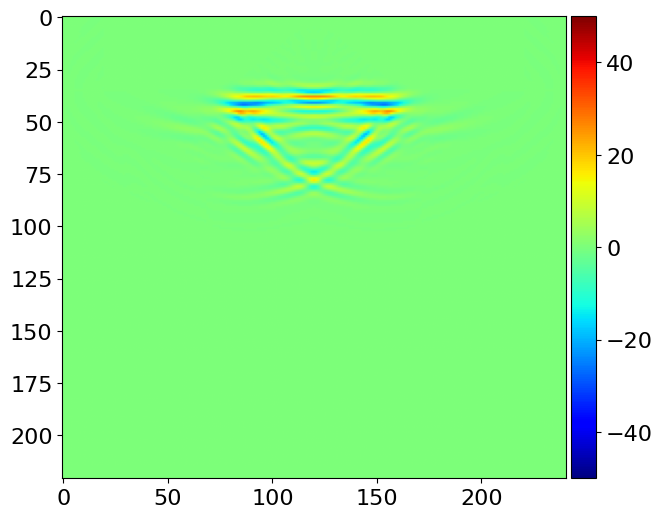

In [12]:
from examples.seismic import plot_image

# Plot the FWI gradient (∂Φ/∂m)
plot_image(-update.data, vmin=-5e1, vmax=5e1, cmap="jet")

In [18]:
from devito import mmax
from examples.seismic.acoustic_topo.ibm_setup import copy_model_params_to_ghosts

n_iter = 10
fwi_history = np.zeros(n_iter)

# Observed data from the true model (computed above)
d_obs_list = [d_obs]

# Start from the smooth model (uniform v=2.0)
model_changing = ModelTopo(origin=origin, spacing=spacing, shape=shape,
                           space_order=4, v=v_init.copy(), rho=rho, topo=topo,
                           nbl=nbl, bcs='mask')

for it in range(n_iter):
    phi, grad = fwi_gradient(model_changing=model_changing, d_obs_list=d_obs_list)
    fwi_history[it] = phi

    # Normalized step: max update in m is ~0.05
    alpha = .05 / mmax(grad)
    model_changing.m.data[:] -= alpha * grad.data

    # Clamp m > 0 (required for sqrt), convert to velocity
    model_changing.m.data[:] = np.maximum(model_changing.m.data, 1e-10)
    model_changing.vp.data[:] = 1.0 / np.sqrt(model_changing.m.data)

    # Re-set ghost-point m values for the updated model
    copy_model_params_to_ghosts(
        model_changing.b.data, model_changing.m.data,
        model_changing.ghost_coords, model_changing.mirror_coords,
        model_changing.origin, model_changing.spacing, model_changing.nbl)

    print(f'Iteration {it+1:3d}: objective = {phi:.3f}')

Operator `initdamp` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Oper

Iteration   1: objective = 1238.717


Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

Iteration   2: objective = 852.808


Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

...

Iteration   8: objective = 478.761


Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

Iteration   9: objective = 2377.532


Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

Iteration  10: objective = 1907.210


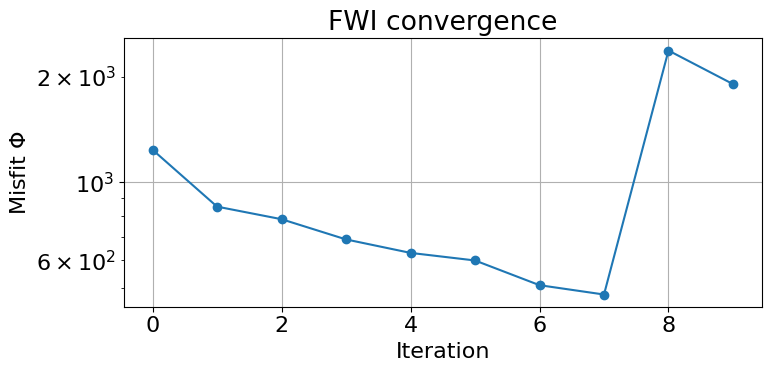

In [19]:
# NBVAL_IGNORE_OUTPUT
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.semilogy(fwi_history, 'o-')
plt.xlabel('Iteration')
plt.ylabel('Misfit $\Phi$')
plt.title('FWI convergence')
plt.grid(True)
plt.tight_layout()
plt.show()

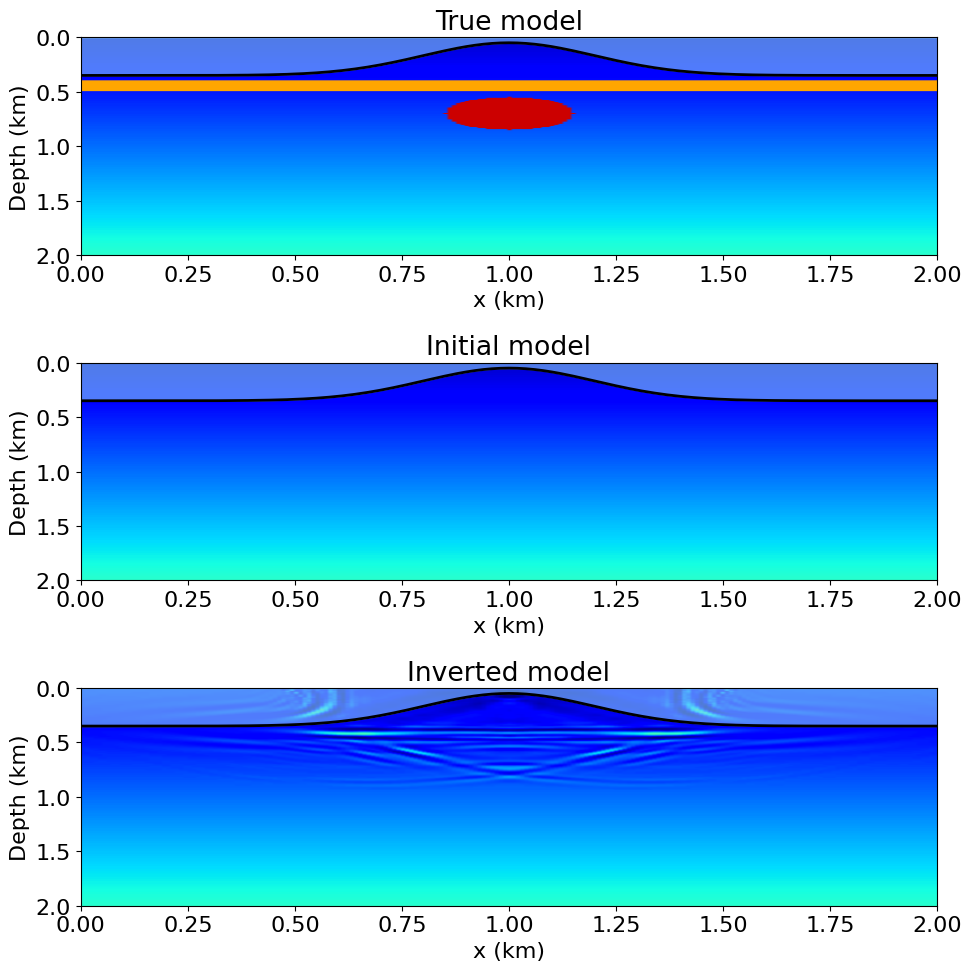

In [ ]:
# NBVAL_IGNORE_OUTPUT
# Compare true, initial, and inverted velocity
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

vmin, vmax = 1.4, 2.9
extent = [x_km[0], x_km[-1], z_km[-1], z_km[0]]

for ax, v_buff, title in zip(axs,
    [v_true, v_init, model_changing.vp.data[nbl:nbl+nx, :nz]],
    ['True model', 'Initial model', 'Inverted model']):
    im = ax.imshow(v_buff.T, cmap='jet', extent=extent,
                   aspect='auto', vmin=vmin, vmax=vmax)
    ax.fill_between(x_km, z_km[0], topo * 1e-3,
                    color='lightskyblue', alpha=0.6)
    ax.plot(x_km, topo * 1e-3, 'k-', lw=2)
    ax.set_xlabel('x (km)')
    ax.set_ylabel('Depth (km)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Results

The FWI gradient was computed for a complex medium with vertical gradient,
a high-velocity layer, and a circular anomaly beneath an irregular free
surface.  The IBM ghost-point correction was applied during both forward
and adjoint (gradient) propagations.

**Key points:**
- Unlike the homogeneous case in notebook 20, the **direct and refracted
  waves** now differ between observed and synthetic data because the true
  model has a layer and inclusion that alter traveltimes.
- These traveltime differences contribute to the gradient alongside
  reflected-wave residuals.
- The gradient is w.r.t. slowness-squared $m = 1/v^2$; updates are applied
  to $m$, then converted back to $v$ for diagnostics.
- After each $m$ update, `copy_model_params_to_ghosts` re-sets ghost-point
  values from mirror-point bilinear interpolation.
- The IBM geometry depends only on topography, not velocity — no
  recomputation is needed during the inversion.